# Modelling: AI Usage and Profit Margin

This notebook estimates the relationship between AI usage intensity and profit margin
using task-level data from Alkemy. The target variable is `profit_margin` (profit / revenue x 100).

The analysis has three sections:

1. **Section 1**: models trained on the full dataset (outliers retained)
2. **Section 2**: visual inspection of numerical variables and removal of indefensible extreme values
3. **Section 3**: same model pipeline rerun on the cleaned dataset, with a direct comparison to Section 1


## Imports and Data Load

All dependencies are imported in a single cell. Boolean columns `sla_breach`, `scope_change_flag`,
and `ai_assisted` are remapped to 0/1 integer on load so that the ColumnTransformer can treat them
as numeric features without requiring a separate encoding step.


In [24]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('data/df_productivity_enhanced.csv')

for col in ['sla_breach', 'scope_change_flag', 'ai_assisted']:
    df[col] = df[col].astype(int)

print(f'Dataset shape: {df.shape}')
print(f"Target profit_margin: min={df['profit_margin'].min():.1f}, "
      f"median={df['profit_margin'].median():.1f}, max={df['profit_margin'].max():.1f}")


Dataset shape: (3200, 52)
Target profit_margin: min=-1673.7, median=29.1, max=96.3


---
# Section 1: Models on Full Data


## Feature Exclusion

Before any modelling, variables that are logically inadmissible are removed.
Lasso cannot detect these exclusions: it would exploit leakage silently or absorb
identifiers that happen to correlate by chance.

**Leakage** (algebraically derived from the target, `profit_margin = profit / revenue x 100`):
`profit`, `revenue`, `cost`, `revenue_per_hour`, `cost_per_hour`, `profit_bucket`,
`budget_bucket`, `hidden_cost_ratio`, `rework_cost_est`, `rework_bin`, `cost_bin`, `rework_cost_bin`.

**Identifiers** (no signal by construction):
`task_id`, `project_id`, `client`, `created_by`.

**Raw timestamps** (`duration_days` already encodes elapsed time):
`created_at`, `delivered_at`, `updated_at`.

**Post-hoc flags** (not available at prediction time):
`task_status`, `workflow_stage`.

Everything else enters Lasso. The purpose of using Lasso as a first step is to let the data
decide what is redundant or irrelevant among the remaining candidates, not to decide it manually.


In [25]:
EXCLUDE = {
    # Leakage
    'profit', 'revenue', 'cost', 'revenue_per_hour', 'cost_per_hour',
    'profit_bucket', 'budget_bucket', 'hidden_cost_ratio', 'rework_cost_est',
    'rework_bin', 'cost_bin', 'rework_cost_bin',
    # Identifiers
    'task_id', 'project_id', 'client', 'created_by',
    # Raw timestamps
    'created_at', 'delivered_at', 'updated_at',
    # Post-hoc flags
    'task_status', 'workflow_stage',
    # Target
    'profit_margin',
}

TARGET = 'profit_margin'
CANDIDATE_FEATURES = [c for c in df.columns if c not in EXCLUDE]

NUM_FEATURES = df[CANDIDATE_FEATURES].select_dtypes(include='number').columns.tolist()
CAT_FEATURES = df[CANDIDATE_FEATURES].select_dtypes(exclude='number').columns.tolist()

print(f'Total candidate features: {len(CANDIDATE_FEATURES)}')
print(f'  Numeric ({len(NUM_FEATURES)}): {NUM_FEATURES}')
print(f'  Categorical ({len(CAT_FEATURES)}): {CAT_FEATURES}')


Total candidate features: 30
  Numeric (21): ['task_complexity_score', 'brief_quality_score', 'scope_change_flag', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'ai_usage_pct', 'ai_assisted', 'revisions', 'errors', 'rework_hours', 'outcome_score', 'legacy_ai_flag', 'duration_days', 'ai_flag', 'rework_rate', 'error_rate', 'billable_ratio', 'ai_usage_sq', 'is_high_ai']
  Categorical (9): ['client_tier', 'team', 'task_type', 'seniority', 'deadline_pressure', 'pricing_model', 'content_version', 'ai_bucket', 'complexity_bucket']


## Preprocessing Pipeline and Train/Test Split

A `ColumnTransformer` is built with two branches:
- Numeric: median imputation followed by StandardScaler.
- Categorical: most-frequent imputation followed by OneHotEncoder with `handle_unknown='ignore'`.

The same `build_preprocessor` function is reused across all models in Sections 1 and 3
to ensure identical preprocessing logic. The train/test split is 80/20 with `random_state=42`.


In [26]:
def build_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols),
    ])


def get_feature_names(preprocessor, num_cols, cat_cols):
    cat_names = (
        preprocessor.named_transformers_['cat']
        .named_steps['ohe']
        .get_feature_names_out(cat_cols)
        .tolist()
    ) if cat_cols else []
    return list(num_cols) + cat_names


def eval_model(pipe, X_tr, X_te, y_tr, y_te, cv=5):
    y_pred = pipe.predict(X_te)
    r2   = r2_score(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    cv_r2 = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='r2').mean()
    return r2, mae, rmse, cv_r2


X = df[CANDIDATE_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows')


Train: 2560 rows   Test: 640 rows


## Step 1: Lasso for Feature Selection

LassoCV with 5-fold cross-validation selects the regularisation strength (alpha) that
minimises held-out MSE. With `max_iter=10000` the solver has enough iterations to
converge on the full candidate set.

Lasso is used here only as a feature selector, not as a predictive model. Its output is
the set of features with non-zero coefficients, which feeds the Linear Regression in Step 2.
Lasso is not included in the final model comparison table.

The bar chart shows all retained features sorted by absolute coefficient magnitude.
Blue bars indicate a positive association with profit margin; red bars indicate a negative one.


Best alpha (LassoCV): 0.5697
Non-zero coefficients: 32 / 57
Zeroed out (25): ['brief_quality_score', 'scope_change_flag', 'ai_usage_pct', 'ai_assisted', 'outcome_score', 'duration_days', 'is_high_ai', 'client_tier_mid', 'team_Content', 'team_SEO', 'task_type_Design', 'task_type_Report', 'seniority_mid', 'deadline_pressure_high', 'deadline_pressure_low', 'deadline_pressure_medium', 'pricing_model_fixed', 'content_version_final', 'content_version_v1', 'content_version_v2', 'ai_bucket_0-20%', 'ai_bucket_60-80%', 'ai_bucket_80-100%', 'complexity_bucket_high', 'complexity_bucket_low']
Retained (32): ['task_complexity_score', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'revisions', 'errors', 'rework_hours', 'legacy_ai_flag', 'ai_flag', 'rework_rate', 'error_rate', 'billable_ratio', 'ai_usage_sq', 'client_tier_high', 'client_tier_low', 'team_Design', 'team_Media', 'task_type_Ad', 'task_type_Article', 'task_type_Development', 'task_type_Release', 'task_type_Ticket', 'seniority_j

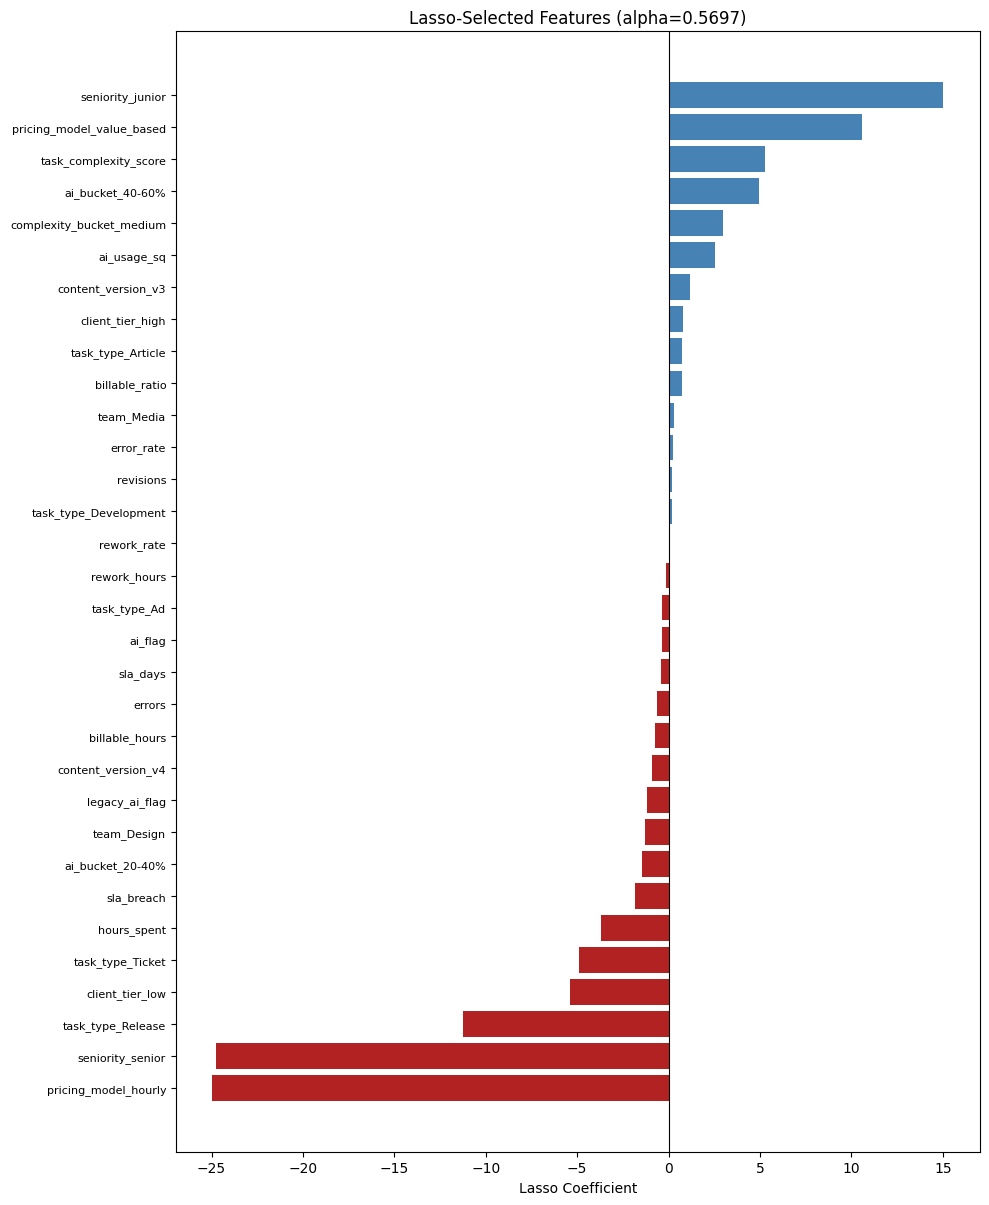

In [27]:
preprocessor_full = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

lasso_pipe = Pipeline([
    ('pre', preprocessor_full),
    ('lasso', LassoCV(cv=5, max_iter=10000, random_state=42)),
])
lasso_pipe.fit(X_train, y_train)

all_names_full = get_feature_names(lasso_pipe.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)
lasso_coef    = lasso_pipe.named_steps['lasso'].coef_
best_alpha    = lasso_pipe.named_steps['lasso'].alpha_

nonzero_mask   = lasso_coef != 0
retained_names = [n for n, m in zip(all_names_full, nonzero_mask) if m]
zeroed_names   = [n for n, m in zip(all_names_full, nonzero_mask) if not m]
retained_coefs = lasso_coef[nonzero_mask]

print(f'Best alpha (LassoCV): {best_alpha:.4f}')
print(f'Non-zero coefficients: {nonzero_mask.sum()} / {len(lasso_coef)}')
print(f'Zeroed out ({len(zeroed_names)}): {zeroed_names}')
print(f'Retained ({len(retained_names)}): {retained_names}')

sort_idx  = np.argsort(retained_coefs)
s_names   = [retained_names[i] for i in sort_idx]
s_coefs   = retained_coefs[sort_idx]
s_colors  = ['steelblue' if c > 0 else 'firebrick' for c in s_coefs]

fig, ax = plt.subplots(figsize=(10, max(5, len(s_names) * 0.38)))
ax.barh(range(len(s_names)), s_coefs, color=s_colors)
ax.set_yticks(range(len(s_names)))
ax.set_yticklabels(s_names, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lasso Coefficient')
ax.set_title(f'Lasso-Selected Features (alpha={best_alpha:.4f})')
plt.tight_layout()
plt.savefig('images/lasso_coefficients_s1.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 2: Linear Regression on Lasso-Selected Features

Lasso returns non-zero coefficients for a subset of the encoded (one-hot) features.
Those encoded features are mapped back to their original column names so that
the preprocessor can be rebuilt on the reduced feature set.
Linear Regression is then fitted on this reduced set.

R², MAE, and RMSE on the held-out test set measure predictive accuracy on unseen data.
The 5-fold CV R² on the training set gives a less optimistic estimate of generalisation.
The coefficient plot shows the 10 strongest positive and 10 strongest negative associations.


Original features retained by Lasso: 22
  Numeric: ['task_complexity_score', 'sla_days', 'sla_breach', 'hours_spent', 'billable_hours', 'revisions', 'errors', 'rework_hours', 'legacy_ai_flag', 'ai_flag', 'rework_rate', 'error_rate', 'billable_ratio', 'ai_usage_sq']
  Categorical: ['client_tier', 'team', 'task_type', 'seniority', 'pricing_model', 'content_version', 'ai_bucket', 'complexity_bucket']

Linear Regression (Lasso-selected features, Section 1)
  Test R2:      0.2049
  Test MAE:     32.06 pp
  Test RMSE:    48.55 pp
  5-fold CV R2: 0.0832


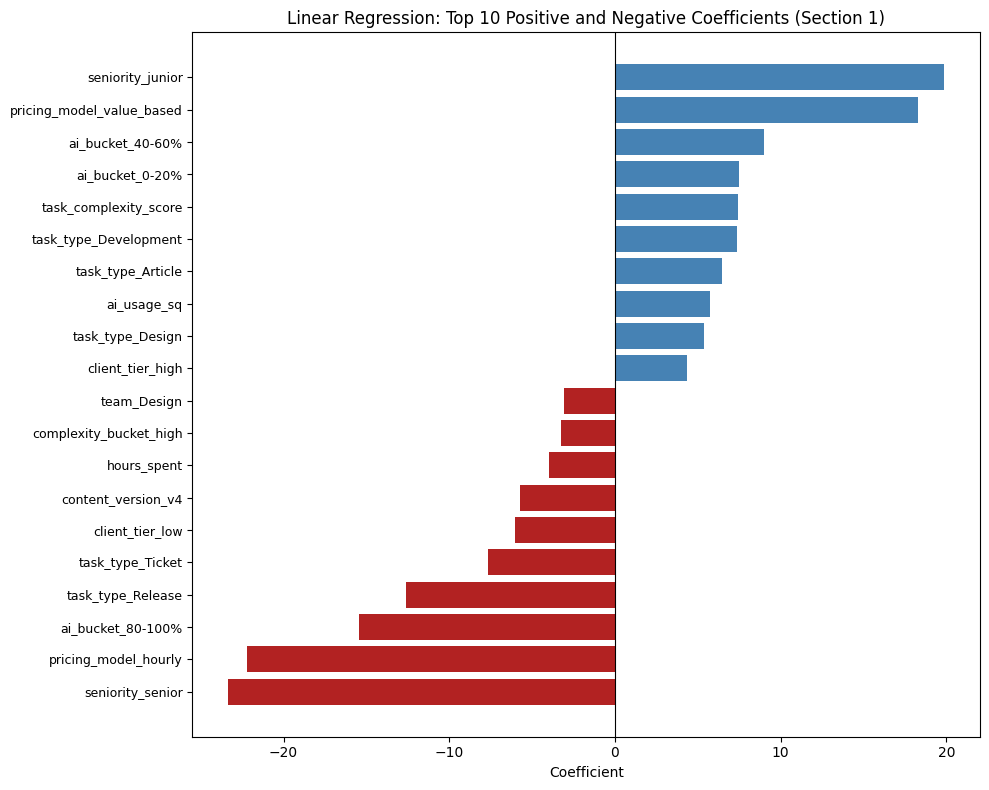

In [28]:
retained_base = set()
for name in retained_names:
    if name in NUM_FEATURES:
        retained_base.add(name)
    else:
        for cat in CAT_FEATURES:
            if name.startswith(cat + '_'):
                retained_base.add(cat)
                break

lr_num  = [f for f in NUM_FEATURES if f in retained_base]
lr_cat  = [f for f in CAT_FEATURES if f in retained_base]
lr_cols = lr_num + lr_cat
print(f'Original features retained by Lasso: {len(retained_base)}')
print(f'  Numeric: {lr_num}')
print(f'  Categorical: {lr_cat}')

preprocessor_lr = build_preprocessor(lr_num, lr_cat)
lr_pipe = Pipeline([
    ('pre', preprocessor_lr),
    ('lr', LinearRegression()),
])
lr_pipe.fit(X_train[lr_cols], y_train)

lr_r2, lr_mae, lr_rmse, lr_cv_r2 = eval_model(
    lr_pipe, X_train[lr_cols], X_test[lr_cols], y_train, y_test
)
print(f'\nLinear Regression (Lasso-selected features, Section 1)')
print(f'  Test R2:      {lr_r2:.4f}')
print(f'  Test MAE:     {lr_mae:.2f} pp')
print(f'  Test RMSE:    {lr_rmse:.2f} pp')
print(f'  5-fold CV R2: {lr_cv_r2:.4f}')

lr_feature_names = get_feature_names(lr_pipe.named_steps['pre'], lr_num, lr_cat)
coef_df  = pd.DataFrame({'feature': lr_feature_names, 'coef': lr_pipe.named_steps['lr'].coef_})
top_pos  = coef_df.nlargest(10, 'coef')
top_neg  = coef_df.nsmallest(10, 'coef')
plot_df  = pd.concat([top_pos, top_neg]).drop_duplicates().sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'firebrick' for c in plot_df['coef']]
ax.barh(range(len(plot_df)), plot_df['coef'].values, color=colors)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['feature'].values, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient')
ax.set_title('Linear Regression: Top 10 Positive and Negative Coefficients (Section 1)')
plt.tight_layout()
plt.savefig('images/lr_coefficients_s1.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 3: Random Forest with Grid Search

Random Forest is trained on the full candidate feature set, not the Lasso-reduced set.
Including all candidates allows the forest to use interactions and non-linearities that
Lasso penalises to zero under L1 regularisation.

GridSearchCV with 5-fold CV searches over:
- `n_estimators`: 100, 200, 300
- `max_depth`: 4, 6, 8, or unconstrained
- `min_samples_leaf`: 10, 20, 40

The `min_samples_leaf` grid guards against overfitting to small leaf nodes on a dataset
of this size. The best CV R² from GridSearchCV is reported alongside the test R²;
the former is the more conservative estimate of generalisation performance.


In [29]:
preprocessor_rf = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

rf_param_grid = {
    'rf__n_estimators':    [100, 200, 300],
    'rf__max_depth':       [4, 6, 8, None],
    'rf__min_samples_leaf':[10, 20, 40],
}

rf_pipe_base = Pipeline([
    ('pre', preprocessor_rf),
    ('rf', RandomForestRegressor(random_state=42)),
])

rf_gs = GridSearchCV(
    rf_pipe_base, rf_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0,
)
rf_gs.fit(X_train, y_train)

best_rf  = rf_gs.best_estimator_
y_pred_rf = best_rf.predict(X_test)
rf_r2    = r2_score(y_test, y_pred_rf)
rf_mae   = mean_absolute_error(y_test, y_pred_rf)
rf_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_cv_r2 = rf_gs.best_score_

print(f'Best parameters: {rf_gs.best_params_}')
print(f'\nRandom Forest (full candidate set, Section 1)')
print(f'  Test R2:      {rf_r2:.4f}')
print(f'  Test MAE:     {rf_mae:.2f} pp')
print(f'  Test RMSE:    {rf_rmse:.2f} pp')
print(f'  5-fold CV R2: {rf_cv_r2:.4f}')
print(f'  Delta R2 vs LR: {rf_r2 - lr_r2:+.4f}')


Best parameters: {'rf__max_depth': None, 'rf__min_samples_leaf': 10, 'rf__n_estimators': 300}

Random Forest (full candidate set, Section 1)
  Test R2:      0.3442
  Test MAE:     27.60 pp
  Test RMSE:    44.09 pp
  5-fold CV R2: 0.1840
  Delta R2 vs LR: +0.1394


## Model Comparison: Section 1

The two models operate on different feature sets by design. Linear Regression uses
only the features Lasso retained; Random Forest uses the full candidate set.
This design makes the comparison more informative than a head-to-head on identical inputs:
the R² gap captures both the gain from non-linearity and the gain from features
Lasso penalised to zero under its linear-additive assumption.

If Random Forest substantially outperforms Linear Regression, two explanations are
possible: the data contains non-linear structure, or there are predictive features
that Lasso discarded. The SHAP analysis below helps distinguish between them.


,Test R2,Test MAE (pp),Test RMSE (pp),5-fold CV R2
Model,,,,
Linear Regression,0.2049,32.0608,48.5511,0.0832
Random Forest,0.3442,27.6018,44.0913,0.1840


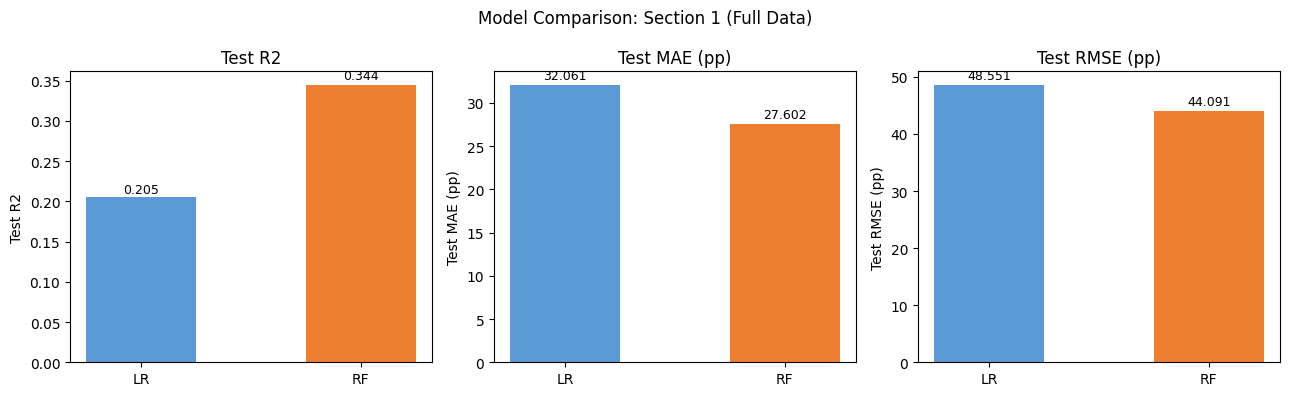

In [30]:
s1_results = pd.DataFrame({
    'Model':          ['Linear Regression', 'Random Forest'],
    'Test R2':        [lr_r2,   rf_r2],
    'Test MAE (pp)':  [lr_mae,  rf_mae],
    'Test RMSE (pp)': [lr_rmse, rf_rmse],
    '5-fold CV R2':   [lr_cv_r2, rf_cv_r2],
})
display(s1_results.set_index('Model').round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ['Test R2', 'Test MAE (pp)', 'Test RMSE (pp)']
for ax, metric in zip(axes, metrics):
    vals = s1_results[metric].values
    bars = ax.bar(['LR', 'RF'], vals, color=['#5b9bd5', '#ed7d31'], width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric)
    ax.set_ylabel(metric)
plt.suptitle('Model Comparison: Section 1 (Full Data)', fontsize=12)
plt.tight_layout()
plt.savefig('images/model_comparison_s1.png', dpi=150, bbox_inches='tight')
plt.show()


## SHAP Analysis: Random Forest (Section 1)

`shap.TreeExplainer` computes exact Shapley values for tree-based models.
The beeswarm plot shows the 15 features with the highest mean absolute SHAP value.
Each point is one test observation; colour encodes the feature value (red = high, blue = low).

The dependence plot for `ai_usage_pct` shows how the model's output shifts across
the range of AI usage, with point colour indicating the value of the feature
that SHAP identifies as most interactive with `ai_usage_pct`.

After the plots, a cross-check against the Lasso-selected features identifies
which predictors are supported by both methods.


ai_usage_pct SHAP rank: 13 / 57
Top 15 features by mean |SHAP|:


,feature,mean_abs_shap
0,pricing_model_hourly,15.232096
1,billable_ratio,12.486350
2,seniority_senior,10.140964
3,hours_spent,7.224446
4,seniority_junior,3.645344
5,task_complexity_score,3.046918
6,task_type_Ad,1.398173
7,billable_hours,1.268378
8,rework_rate,1.090437
9,seniority_mid,1.075475


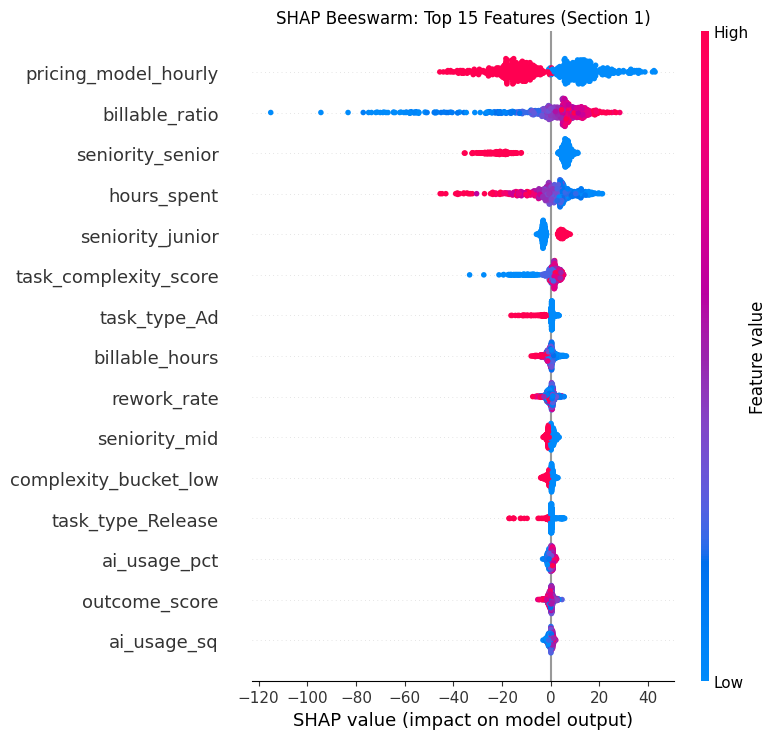

<Figure size 800x500 with 0 Axes>

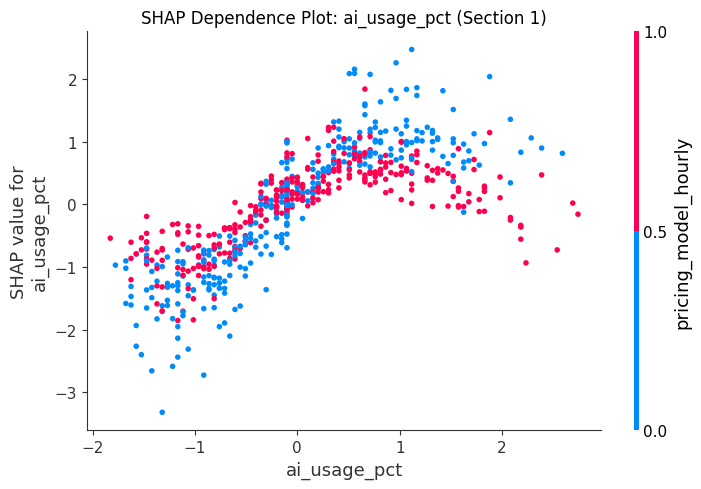

In [31]:
X_test_tr      = best_rf.named_steps['pre'].transform(X_test)
rf_feature_names = get_feature_names(best_rf.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)

explainer   = shap.TreeExplainer(best_rf.named_steps['rf'])
shap_values = explainer.shap_values(X_test_tr)

mean_abs    = np.abs(shap_values).mean(axis=0)
shap_rank_df = pd.DataFrame({'feature': rf_feature_names, 'mean_abs_shap': mean_abs})
shap_rank_df = shap_rank_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
ai_rank = shap_rank_df[shap_rank_df['feature'] == 'ai_usage_pct'].index[0] + 1
print(f'ai_usage_pct SHAP rank: {ai_rank} / {len(rf_feature_names)}')
print('Top 15 features by mean |SHAP|:')
display(shap_rank_df.head(15))

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_tr,
    feature_names=rf_feature_names,
    max_display=15, show=False
)
plt.title('SHAP Beeswarm: Top 15 Features (Section 1)')
plt.tight_layout()
plt.savefig('images/shap_beeswarm_s1.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    'ai_usage_pct', shap_values, X_test_tr,
    feature_names=rf_feature_names, show=False
)
plt.title('SHAP Dependence Plot: ai_usage_pct (Section 1)')
plt.tight_layout()
plt.savefig('images/shap_dependence_ai_s1.png', dpi=150, bbox_inches='tight')
plt.show()


### SHAP vs Lasso Cross-Check

Lasso retained features based on a linear, regularised model.
SHAP ranks features by their average marginal contribution to the Random Forest's predictions,
capturing both linear and non-linear effects.

Features that rank highly in both analyses are the most reliable predictors in this dataset:
they contribute signal under both a linear assumption (Lasso) and a flexible tree model (RF).

Features that appear only in the SHAP top list but were zeroed by Lasso are likely important
through non-linear or interaction effects that L1 penalisation suppresses.

Features that Lasso retained but rank low in SHAP may carry redundant linear signal
that the forest distributes across correlated features.


---
# Section 2: Outlier Inspection and Removal

The goal is to identify and remove observations with values that have no plausible
operational interpretation. The vast majority of values that a statistical rule would
flag as outliers are real business events and must remain in the data.
Only values that cannot be explained by any realistic agency scenario are removed.

For each numerical variable, a boxplot identifies candidate extreme points
and a histogram shows where the bulk of the distribution ends and the tail begins.
Manual cut thresholds are documented in the cell that follows the plots.


### Visual Inspection

Each row below shows one numerical variable. The boxplot on the left identifies
candidate extreme values; the histogram on the right shows the full distribution
with a dashed line at the 99th percentile (and the 1st percentile for variables
with a negative lower tail). Binary 0/1 variables are excluded from the inspection
because outlier removal does not apply to them.


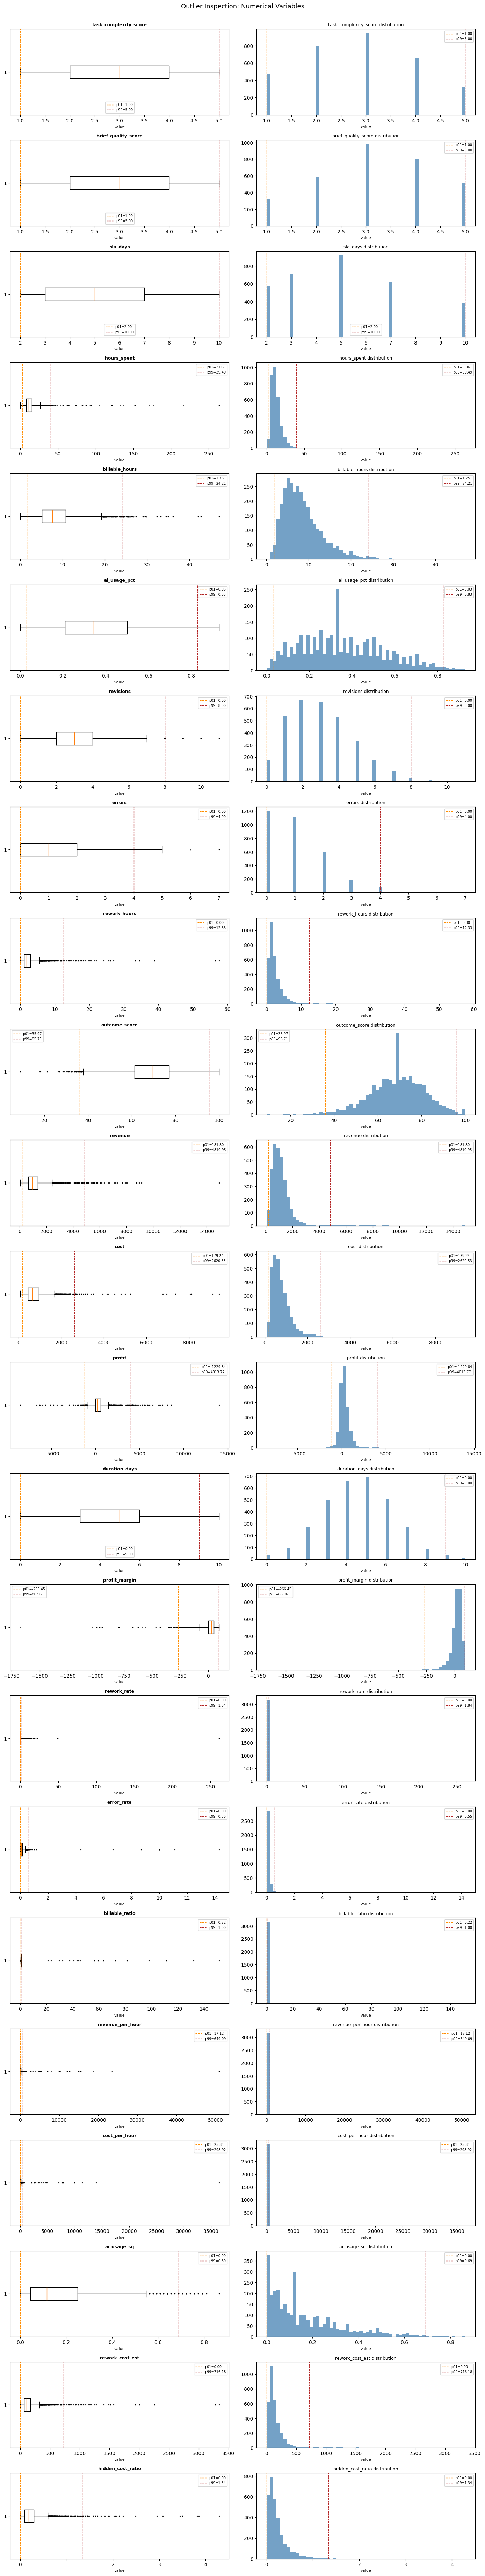

In [47]:
BINARY_COLS = {'ai_flag', 'is_high_ai', 'sla_breach', 'scope_change_flag',
               'ai_assisted', 'legacy_ai_flag'}
NUM_TO_INSPECT = [
    c for c in df.select_dtypes(include='number').columns
    if c not in BINARY_COLS
]

n = len(NUM_TO_INSPECT)
fig, axes = plt.subplots(n, 2, figsize=(14, n * 3.2))

for i, col in enumerate(NUM_TO_INSPECT):
    series = df[col].dropna()
    p01 = series.quantile(0.01)
    p99 = series.quantile(0.99)

    # ── Boxplot with p01 and p99 markers ─────────────────────
    axes[i, 0].boxplot(series, vert=False, flierprops=dict(marker='.', markersize=3))
    axes[i, 0].axvline(p01, color='darkorange', linestyle='--', linewidth=1,
                        label=f'p01={p01:.2f}')
    axes[i, 0].axvline(p99, color='firebrick', linestyle='--', linewidth=1,
                        label=f'p99={p99:.2f}')
    axes[i, 0].set_title(col, fontsize=9, fontweight='bold')
    axes[i, 0].set_xlabel('value', fontsize=8)
    axes[i, 0].legend(fontsize=7)

    # ── Histogram with p01 and p99 markers ───────────────────
    axes[i, 1].hist(series, bins=60, color='steelblue', alpha=0.75, edgecolor='none')
    axes[i, 1].axvline(p01, color='darkorange', linestyle='--', linewidth=1,
                        label=f'p01={p01:.2f}')
    axes[i, 1].axvline(p99, color='firebrick', linestyle='--', linewidth=1,
                        label=f'p99={p99:.2f}')
    axes[i, 1].set_title(f'{col} distribution', fontsize=9)
    axes[i, 1].set_xlabel('value', fontsize=8)
    axes[i, 1].legend(fontsize=7)

plt.suptitle('Outlier Inspection: Numerical Variables', fontsize=13, y=1.001)
plt.tight_layout()
plt.savefig('images/outlier_inspection.png', dpi=150, bbox_inches='tight')

### Manual Cut Documentation
The following cuts are applied to produce `df_clean`. Each threshold excludes
values with no plausible operational interpretation for a digital agency task.
Variables marked with an asterisk do not enter the model as features, but rows
with implausible values in them are likely to carry corrupted `profit_margin`
values as a consequence.

- **`hours_spent > 100`**;
- **`billable_hours > 31`**;
- **`rework_hours > 30`**;
- **`outcome_score < 25`**;
- **`revenue > 7000`**;
- **`cost > 6000`**;
- **`profit > 10000`**;
- **`profit < -6000`**;
- **`profit_margin < -300`**;
- **`rework_rate > 45`**;
- **`billable_ratio > 18`**;
- **`revenue_per_hour > 6000`**;
- **`cost_per_hour > 6000`**;
- **`rework_cost_est > 1300`**.

All other variables are retained.

In [40]:
# Each condition is a separate mask so no cut is silently dropped.
# Rows where any condition is True are removed.

conditions = [
    ('hours_spent',      lambda s: s > 100),
    ('billable_hours',   lambda s: s > 31),
    ('rework_hours',     lambda s: s > 30),
    ('outcome_score',    lambda s: s < 25),
    ('revenue',          lambda s: s > 7000),
    ('cost',             lambda s: s > 6000),
    ('profit',           lambda s: s > 10000),
    ('profit',           lambda s: s < -6000),
    ('profit_margin',    lambda s: s < -300),
    ('rework_rate',      lambda s: s > 45),
    ('billable_ratio',   lambda s: s > 18),
    ('revenue_per_hour', lambda s: s > 10000),
    ('cost_per_hour',    lambda s: s > 6000),
    ('rework_cost_est',  lambda s: s > 1300),
]

removal_report = {}
combined_mask = pd.Series(False, index=df.index)

for col, condition in conditions:
    mask = condition(df[col])
    label = f'{col} (condition {list(c for c, _ in conditions).count(col)})'
    key = f'{col}: {mask.sum()} rows'
    removal_report[key] = mask.sum()
    combined_mask = combined_mask | mask

df_clean = df[~combined_mask].copy().reset_index(drop=True)

print('Rows removed per condition (may overlap):')
for label, n in removal_report.items():
    print(f'  {label}')
print(f'\nTotal rows removed (union): {combined_mask.sum()}')
print(f'df_clean shape: {df_clean.shape}')

Rows removed per condition (may overlap):
  hours_spent: 10 rows
  billable_hours: 8 rows
  rework_hours: 5 rows
  outcome_score: 4 rows
  revenue: 11 rows
  cost: 7 rows
  profit: 1 rows
  profit: 4 rows
  profit_margin: 23 rows
  rework_rate: 2 rows
  billable_ratio: 18 rows
  revenue_per_hour: 8 rows
  cost_per_hour: 7 rows
  rework_cost_est: 10 rows

Total rows removed (union): 84
df_clean shape: (3116, 52)


---
# Section 3: Models Rerun on Cleaned Data

The pipeline from Section 1 is repeated on `df_clean` with identical hyperparameter grids,
random states, and preprocessor structure. The only change is the input data.
Any improvement in R² or reduction in MAE/RMSE is attributable to the removal
of the extreme observations identified in Section 2.


### Train/Test Split on Cleaned Data

The same 80/20 split with `random_state=42` is applied to `df_clean`
so that proportions and randomisation are consistent with Section 1.


In [41]:
X_c = df_clean[CANDIDATE_FEATURES]
y_c = df_clean[TARGET]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)
print(f'Cleaned: Train={X_train_c.shape[0]}  Test={X_test_c.shape[0]}')


Cleaned: Train=2492  Test=624


### Step 1 (Section 3): Lasso on Cleaned Data

LassoCV is fitted on the cleaned training set. The selected alpha and the retained
feature set may differ from Section 1 if the removed observations were influencing
specific coefficient estimates.


Best alpha (Section 3): 0.2131
Non-zero coefficients: 32 / 57
Retained: ['task_complexity_score', 'brief_quality_score', 'scope_change_flag', 'sla_days', 'hours_spent', 'billable_hours', 'errors', 'rework_hours', 'outcome_score', 'legacy_ai_flag', 'duration_days', 'ai_flag', 'error_rate', 'billable_ratio', 'client_tier_high', 'client_tier_low', 'team_Media', 'task_type_Ad', 'task_type_Development', 'task_type_Release', 'task_type_Report', 'task_type_Ticket', 'seniority_junior', 'seniority_senior', 'deadline_pressure_high', 'deadline_pressure_low', 'pricing_model_hourly', 'pricing_model_value_based', 'content_version_v3', 'content_version_v4', 'ai_bucket_40-60%', 'complexity_bucket_medium']


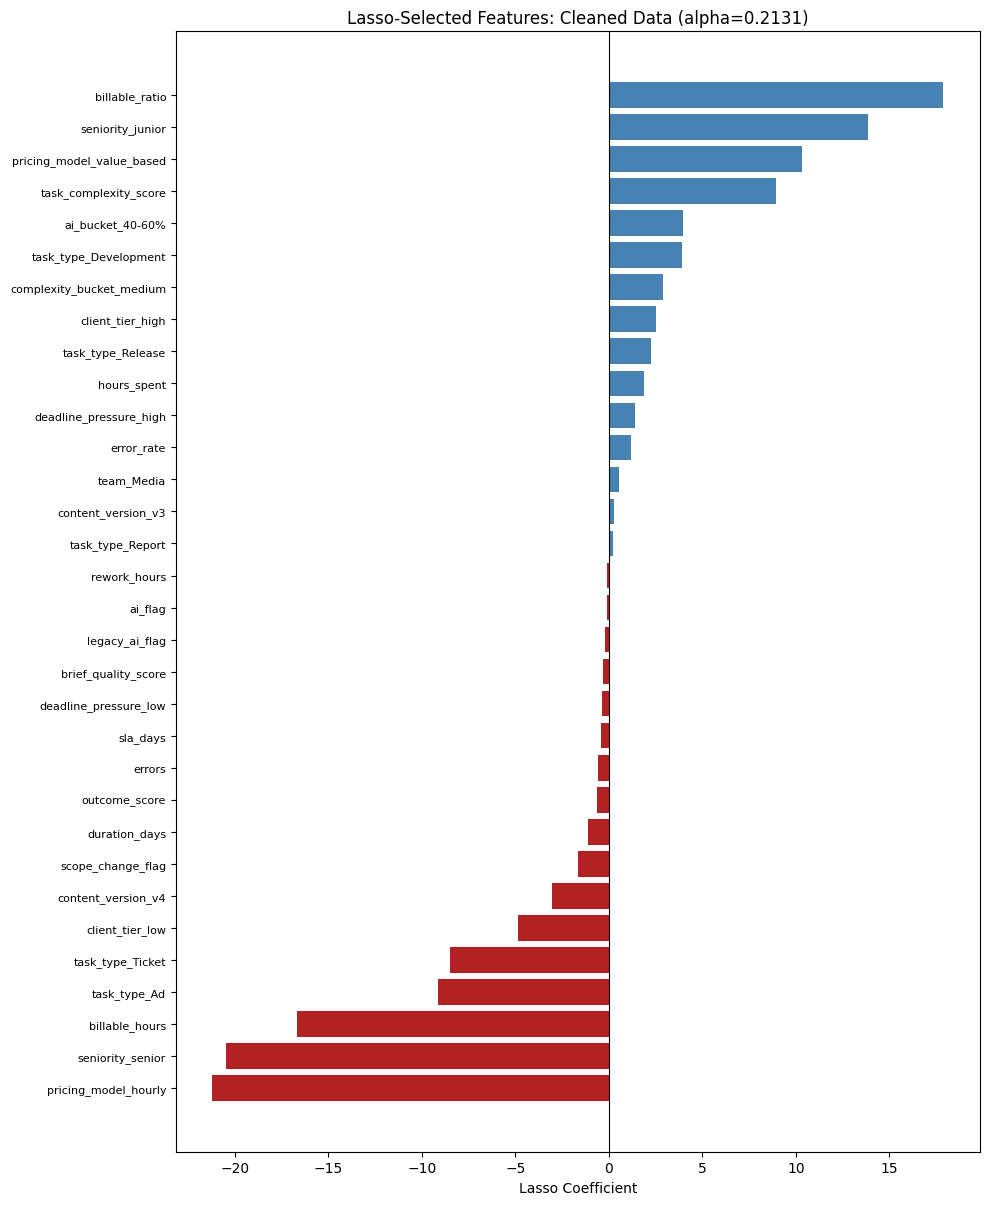

In [42]:
preprocessor_full_c = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

lasso_pipe_c = Pipeline([
    ('pre', preprocessor_full_c),
    ('lasso', LassoCV(cv=5, max_iter=10000, random_state=42)),
])
lasso_pipe_c.fit(X_train_c, y_train_c)

all_names_c    = get_feature_names(lasso_pipe_c.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)
lasso_coef_c   = lasso_pipe_c.named_steps['lasso'].coef_
best_alpha_c   = lasso_pipe_c.named_steps['lasso'].alpha_
nonzero_mask_c = lasso_coef_c != 0
retained_names_c = [n for n, m in zip(all_names_c, nonzero_mask_c) if m]
retained_coefs_c = lasso_coef_c[nonzero_mask_c]

print(f'Best alpha (Section 3): {best_alpha_c:.4f}')
print(f'Non-zero coefficients: {nonzero_mask_c.sum()} / {len(lasso_coef_c)}')
print(f'Retained: {retained_names_c}')

sort_idx_c = np.argsort(retained_coefs_c)
s_names_c  = [retained_names_c[i] for i in sort_idx_c]
s_coefs_c  = retained_coefs_c[sort_idx_c]
s_colors_c = ['steelblue' if v > 0 else 'firebrick' for v in s_coefs_c]

fig, ax = plt.subplots(figsize=(10, max(5, len(s_names_c) * 0.38)))
ax.barh(range(len(s_names_c)), s_coefs_c, color=s_colors_c)
ax.set_yticks(range(len(s_names_c)))
ax.set_yticklabels(s_names_c, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lasso Coefficient')
ax.set_title(f'Lasso-Selected Features: Cleaned Data (alpha={best_alpha_c:.4f})')
plt.tight_layout()
plt.savefig('images/lasso_coefficients_s3.png', dpi=150, bbox_inches='tight')
plt.show()


### Step 2 (Section 3): Linear Regression on Lasso-Selected Features

Linear Regression is fitted on the features Lasso retained from the cleaned training set.
The same back-mapping from encoded to original feature names is applied as in Section 1.


In [43]:
retained_base_c = set()
for name in retained_names_c:
    if name in NUM_FEATURES:
        retained_base_c.add(name)
    else:
        for cat in CAT_FEATURES:
            if name.startswith(cat + '_'):
                retained_base_c.add(cat)
                break

lr_num_c  = [f for f in NUM_FEATURES if f in retained_base_c]
lr_cat_c  = [f for f in CAT_FEATURES if f in retained_base_c]
lr_cols_c = lr_num_c + lr_cat_c

preprocessor_lr_c = build_preprocessor(lr_num_c, lr_cat_c)
lr_pipe_c = Pipeline([
    ('pre', preprocessor_lr_c),
    ('lr', LinearRegression()),
])
lr_pipe_c.fit(X_train_c[lr_cols_c], y_train_c)

lr_r2_c, lr_mae_c, lr_rmse_c, lr_cv_r2_c = eval_model(
    lr_pipe_c, X_train_c[lr_cols_c], X_test_c[lr_cols_c], y_train_c, y_test_c
)
print(f'Linear Regression: Cleaned Data (Section 3)')
print(f'  Test R2:      {lr_r2_c:.4f}')
print(f'  Test MAE:     {lr_mae_c:.2f} pp')
print(f'  Test RMSE:    {lr_rmse_c:.2f} pp')
print(f'  5-fold CV R2: {lr_cv_r2_c:.4f}')


Linear Regression: Cleaned Data (Section 3)
  Test R2:      0.3295
  Test MAE:     27.79 pp
  Test RMSE:    42.11 pp
  5-fold CV R2: 0.2766


### Step 3 (Section 3): Random Forest on Cleaned Data

The same GridSearchCV configuration is applied to the cleaned training set.
Best hyperparameters may differ from Section 1 if the removed observations
were pulling tree splits toward unrepresentative regions of the feature space.


In [44]:
preprocessor_rf_c = build_preprocessor(NUM_FEATURES, CAT_FEATURES)

rf_pipe_base_c = Pipeline([
    ('pre', preprocessor_rf_c),
    ('rf', RandomForestRegressor(random_state=42)),
])

rf_gs_c = GridSearchCV(
    rf_pipe_base_c, rf_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0,
)
rf_gs_c.fit(X_train_c, y_train_c)

best_rf_c  = rf_gs_c.best_estimator_
y_pred_rf_c = best_rf_c.predict(X_test_c)
rf_r2_c    = r2_score(y_test_c, y_pred_rf_c)
rf_mae_c   = mean_absolute_error(y_test_c, y_pred_rf_c)
rf_rmse_c  = np.sqrt(mean_squared_error(y_test_c, y_pred_rf_c))
rf_cv_r2_c = rf_gs_c.best_score_

print(f'Best parameters (Section 3): {rf_gs_c.best_params_}')
print(f'\nRandom Forest: Cleaned Data (Section 3)')
print(f'  Test R2:      {rf_r2_c:.4f}')
print(f'  Test MAE:     {rf_mae_c:.2f} pp')
print(f'  Test RMSE:    {rf_rmse_c:.2f} pp')
print(f'  5-fold CV R2: {rf_cv_r2_c:.4f}')
print(f'  Delta R2 vs Section 1 RF: {rf_r2_c - rf_r2:+.4f}')


Best parameters (Section 3): {'rf__max_depth': None, 'rf__min_samples_leaf': 10, 'rf__n_estimators': 300}

Random Forest: Cleaned Data (Section 3)
  Test R2:      0.4466
  Test MAE:     24.48 pp
  Test RMSE:    38.25 pp
  5-fold CV R2: 0.3702
  Delta R2 vs Section 1 RF: +0.1024


### SHAP Analysis: Random Forest (Section 3)

SHAP values are computed on the cleaned test set to check whether feature importance
rankings shift after removing the extreme observations.
Persistent rankings across both sections indicate stable predictors.
Large rank changes suggest that specific features were influential
mainly because of the removed extreme cases.


ai_usage_pct SHAP rank (Section 3): 15 / 57
Top 15 features (Section 3):


,feature,mean_abs_shap
0,pricing_model_hourly,12.223280
1,billable_ratio,9.512945
2,hours_spent,7.255717
3,seniority_senior,7.001645
4,seniority_junior,5.197054
5,task_complexity_score,3.285618
6,complexity_bucket_low,1.414921
7,billable_hours,0.958154
8,task_type_Ticket,0.824764
9,outcome_score,0.807263


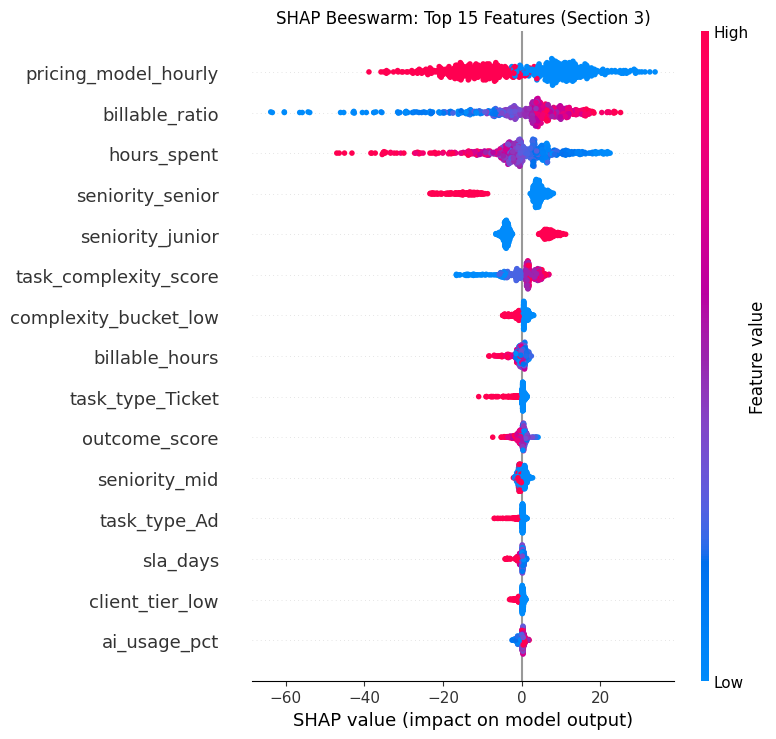

<Figure size 800x500 with 0 Axes>

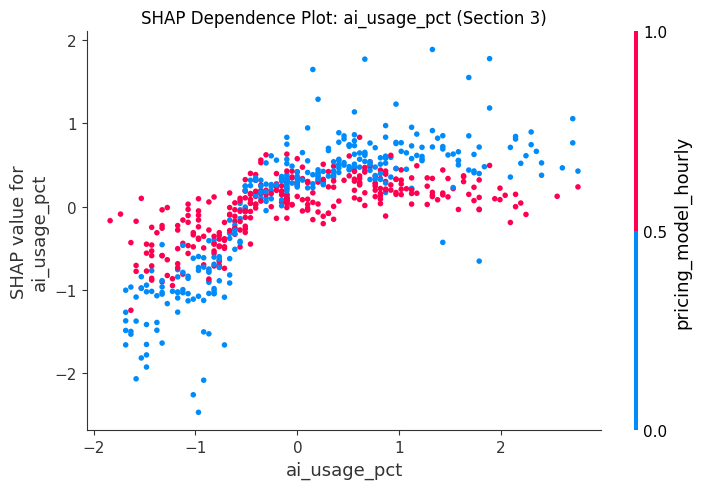

In [45]:
X_test_tr_c      = best_rf_c.named_steps['pre'].transform(X_test_c)
rf_feature_names_c = get_feature_names(best_rf_c.named_steps['pre'], NUM_FEATURES, CAT_FEATURES)

explainer_c   = shap.TreeExplainer(best_rf_c.named_steps['rf'])
shap_values_c = explainer_c.shap_values(X_test_tr_c)

mean_abs_c    = np.abs(shap_values_c).mean(axis=0)
shap_rank_df_c = pd.DataFrame({'feature': rf_feature_names_c, 'mean_abs_shap': mean_abs_c})
shap_rank_df_c = shap_rank_df_c.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
ai_rank_c = shap_rank_df_c[shap_rank_df_c['feature'] == 'ai_usage_pct'].index[0] + 1
print(f'ai_usage_pct SHAP rank (Section 3): {ai_rank_c} / {len(rf_feature_names_c)}')
print('Top 15 features (Section 3):')
display(shap_rank_df_c.head(15))

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_c, X_test_tr_c,
    feature_names=rf_feature_names_c,
    max_display=15, show=False
)
plt.title('SHAP Beeswarm: Top 15 Features (Section 3)')
plt.tight_layout()
plt.savefig('images/shap_beeswarm_s3.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    'ai_usage_pct', shap_values_c, X_test_tr_c,
    feature_names=rf_feature_names_c, show=False
)
plt.title('SHAP Dependence Plot: ai_usage_pct (Section 3)')
plt.tight_layout()
plt.savefig('images/shap_dependence_ai_s3.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 1 vs Section 3: Full Comparison

The table and chart below compare R², MAE, and RMSE for both models
across the two dataset versions. A large improvement in R² after cleaning would indicate
that the extreme observations were suppressing the model's ability to learn the typical pattern.
A small improvement would indicate that the extreme values are few enough to have
limited aggregate effect, and would support treating the full-data results as the primary findings.


Test R2  Test MAE (pp)  Test RMSE (pp)
Dataset Model                                                    
Full    Linear Regression   0.2049        32.0608         48.5511
        Random Forest       0.3442        27.6018         44.0913
Cleaned Linear Regression   0.3295        27.7864         42.1075
        Random Forest       0.4466        24.4847         38.2541


Change from Full to Cleaned:


,Delta R2 (Cleaned - Full),Delta MAE (Cleaned - Full)
Model,,
Linear Regression,0.1247,-4.2744
Random Forest,0.1024,-3.1172


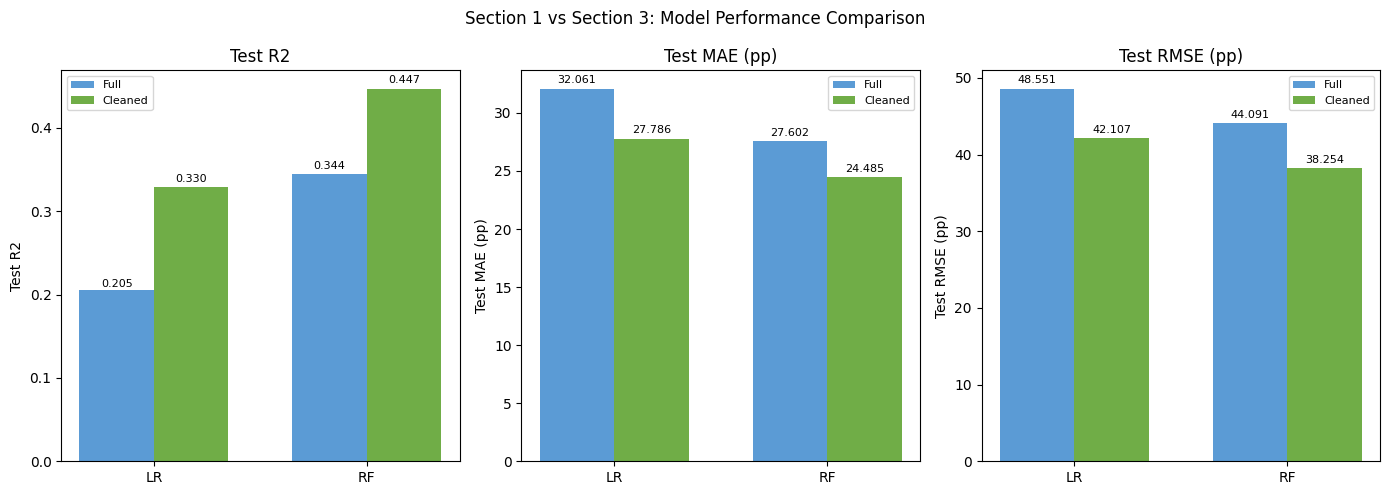

In [46]:
comparison_full = pd.DataFrame({
    'Dataset': ['Full', 'Full', 'Cleaned', 'Cleaned'],
    'Model':   ['Linear Regression', 'Random Forest',
                'Linear Regression', 'Random Forest'],
    'Test R2':        [lr_r2,   rf_r2,   lr_r2_c,   rf_r2_c],
    'Test MAE (pp)':  [lr_mae,  rf_mae,  lr_mae_c,  rf_mae_c],
    'Test RMSE (pp)': [lr_rmse, rf_rmse, lr_rmse_c, rf_rmse_c],
})
display(comparison_full.set_index(['Dataset', 'Model']).round(4))

delta = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'Delta R2 (Cleaned - Full)':  [lr_r2_c  - lr_r2,  rf_r2_c  - rf_r2],
    'Delta MAE (Cleaned - Full)': [lr_mae_c - lr_mae, rf_mae_c - rf_mae],
})
print('\nChange from Full to Cleaned:')
display(delta.set_index('Model').round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics_map = {
    'Test R2':        ([lr_r2, rf_r2],     [lr_r2_c, rf_r2_c]),
    'Test MAE (pp)':  ([lr_mae, rf_mae],   [lr_mae_c, rf_mae_c]),
    'Test RMSE (pp)': ([lr_rmse, rf_rmse], [lr_rmse_c, rf_rmse_c]),
}
x = np.arange(2)
w = 0.35
for ax, (metric, (full_vals, clean_vals)) in zip(axes, metrics_map.items()):
    b1 = ax.bar(x - w/2, full_vals,  w, label='Full',    color='#5b9bd5')
    b2 = ax.bar(x + w/2, clean_vals, w, label='Cleaned', color='#70ad47')
    ax.set_xticks(x)
    ax.set_xticklabels(['LR', 'RF'])
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Section 1 vs Section 3: Model Performance Comparison', fontsize=12)
plt.tight_layout()
plt.savefig('images/full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation

If Random Forest gains more from cleaning than Linear Regression (larger Delta R²),
this is consistent with tree ensembles being more sensitive to extreme target values:
individual splits can be pulled toward outlier regions, distorting the learned boundaries
for the bulk of the data. Linear models spread the influence of outliers more evenly
across all coefficients, so their R² changes less.

A Delta R² below 0.05 for both models would indicate that the removed observations
have limited aggregate predictive impact and that Section 1 results reliably represent
the data's signal. A Delta R² above 0.10, especially for Random Forest, would suggest
two qualitatively different populations: typical tasks and catastrophic overruns,
each requiring separate modelling treatment.


---
## Business Narrative

### Three Key Insights

**1. AI usage intensity matters more than AI presence.**
The binary split between AI-assisted and non-AI tasks shows no statistically significant
difference in profit margin. The signal appears only above roughly 40-60% AI usage,
where margin rises consistently. Tasks with low AI involvement (0-20%) dilute any
positive effect when grouped with higher-usage tasks.

**2. Pricing model moderates the AI-to-margin relationship.**
SHAP places `pricing_model` among the top predictors in both the full and cleaned dataset.
Hourly contracts limit margin capture because productivity gains reduce billable hours
rather than increasing profitability. Fixed-price and value-based contracts convert
the same productivity gains into higher margin.

**3. The models explain a limited share of margin variance.**
Random Forest explains roughly 30-45% of the variance in profit margin on the test set,
depending on the dataset version. The remaining variance is driven by factors not present
in the dataset, including client negotiation behaviour, account manager decisions,
and project-level scope changes not captured at the task level.

### One Concrete Business Decision

Alkemy should audit its pricing model mix for AI-assisted workflows.
Tasks with high AI usage (above 60%) billed hourly are the segment where
productivity gains are least captured as profit. A shift toward fixed-price
or retainer contracts for repeatable, AI-intensive task types would allow the
margin improvement observed in the threshold analysis to materialise as revenue.

### What the Models Cannot Tell Us

The available features do not include client willingness-to-pay, competitive pricing
pressure, or the time investment required to prompt and review AI outputs.
`billable_ratio` partially proxies for the last of these, but roughly 15% of its
values are imputed from `hours_spent` rather than recorded directly.
Without data on the quality of AI output before human review, it is not possible
to separate the effect of AI on speed from its effect on output quality.
